# DS4420 Project: Predicting Gold Prices with Machine Learning Models
### By Justin Wee & Andy Lin 

In [18]:
# Import Libraries
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt


In [2]:
gold_data = pd.read_csv('gold.csv')
gold_data.head(10)

,Date,USD,EUR,JPY,GBP,CAD,CHF,INR,CNY,TRY,SAR,IDR,AED,THB,VND,EGP,KRW,RUB,ZAR,AUD
0,1/31/78,207.8,129.2,NaN,104.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2/28/78,227.3,139.5,"44,853.10",113.3,269.5,378.8,NaN,NaN,NaN,754.1,"141,796.40",869.4,"4,582.20",NaN,NaN,"111,186.60",NaN,197,198.6
2,3/31/78,245.7,151.3,"49,213.20",122.5,293.2,410.6,NaN,NaN,NaN,822.3,"153,099.60",939.1,"4,949.50",NaN,NaN,"118,284.00",NaN,209.9,216.7
3,4/28/78,242.1,149.3,"49,989.40",118.8,284.2,407.3,NaN,NaN,NaN,810.1,"151,068.50",926.2,"4,884.50",NaN,NaN,"116,507.10",NaN,204.4,215.9
4,5/31/78,239.2,148.8,"51,707.20",115.4,274.2,410.5,NaN,NaN,NaN,817.3,"149,744.30",919.9,"4,842.60",NaN,NaN,"115,555.90",NaN,202.8,215.8
5,6/30/78,257.6,161,"56,429.30",125.2,297.7,445.4,NaN,NaN,NaN,870.7,"160,957.00",983.5,"5,208.50",NaN,NaN,"124,738.20",NaN,217.6,233
6,7/31/78,279.1,173,"61,069.30",132.1,327.4,474.5,NaN,NaN,NaN,941.3,"172,550.10","1,064.80","5,592.20",NaN,NaN,"132,563.70",NaN,235.6,251.1
7,8/31/78,294.7,178.2,"63,843.10",130.5,343,486.1,NaN,NaN,NaN,980.4,"182,837.90","1,109.80","5,881.50",NaN,NaN,"137,305.90",NaN,248.5,261.4
8,9/29/78,300.8,182,"65,530.20",134.5,352,498.5,NaN,NaN,NaN,"1,024.80","190,103.60","1,147.10","6,194.90",NaN,NaN,"148,383.20",NaN,252,266.6
9,10/31/78,355.1,212.4,"78,779.20",161.6,413,571.4,NaN,NaN,NaN,"1,189.70","221,560.70","1,343.10","7,260.90",NaN,NaN,"175,525.80",NaN,294.6,314.7


### Data Preprocessing

In [39]:
# Collect only the date and USD column, and impute the data that is pre-2015
gold_data_clean = gold_data[['Date', 'USD']]
gold_data_clean['USD'] = gold_data_clean['USD'].str.replace(',', '').astype(float)
gold_data_clean['Date'] = pd.to_datetime(gold_data_clean['Date'])
gold_data_clean = gold_data_clean[gold_data_clean['Date'] >= '2018-01-01']

# create time index
gold_data_clean['t'] = range(len(gold_data_clean))

# change to log-price
gold_data_clean['log_price'] = np.log(gold_data_clean['USD'])
gold_data_clean.head()

/var/folders/xf/yl_hrg956yx5xsbpcbt25ds00000gn/T/ipykernel_10629/2517233607.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold_data_clean['USD'] = gold_data_clean['USD'].str.replace(',', '').astype(float)
/var/folders/xf/yl_hrg956yx5xsbpcbt25ds00000gn/T/ipykernel_10629/2517233607.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gold_data_clean['Date'] = pd.to_datetime(gold_data_clean['Date'])
/var/folders/xf/yl_hrg956yx5xsbpcbt25ds00000gn/T/ipykernel_10629/2517233607.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

,Date,USD,t,log_price
480,2018-01-31,1331.7,0,7.194212
481,2018-02-28,1331.5,1,7.194061
482,2018-03-30,1324.7,2,7.188941
483,2018-04-30,1334.7,3,7.196462
484,2018-05-31,1303.0,4,7.172425


### Bayesian Regression

In [41]:
y = gold_data_clean['log_price'].values

y_lag = y[:-1]
y_curr = y[1:]

with pm.Model() as model:
    
    # Priors
    beta_0 = pm.Normal("beta_0", mu=0, sigma=1)
    phi = pm.Normal("phi", mu=0.9, sigma=0.1)
    sigma = pm.HalfNormal("sigma", sigma=1)
    
    # AR(1) mean
    mu = beta_0 + phi * y_lag
    
    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_curr)
    
    # Sample posterior
    trace = pm.sample(500, tune=200, target_accept=0.9)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, phi, sigma]


Output()

Sampling 4 chains for 200 tune and 500 draw iterations (800 + 2_000 draws total) took 608 seconds.


array([[<Axes: title={'center': 'beta_0'}>,
        <Axes: title={'center': 'beta_0'}>],
       [<Axes: title={'center': 'phi'}>, <Axes: title={'center': 'phi'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

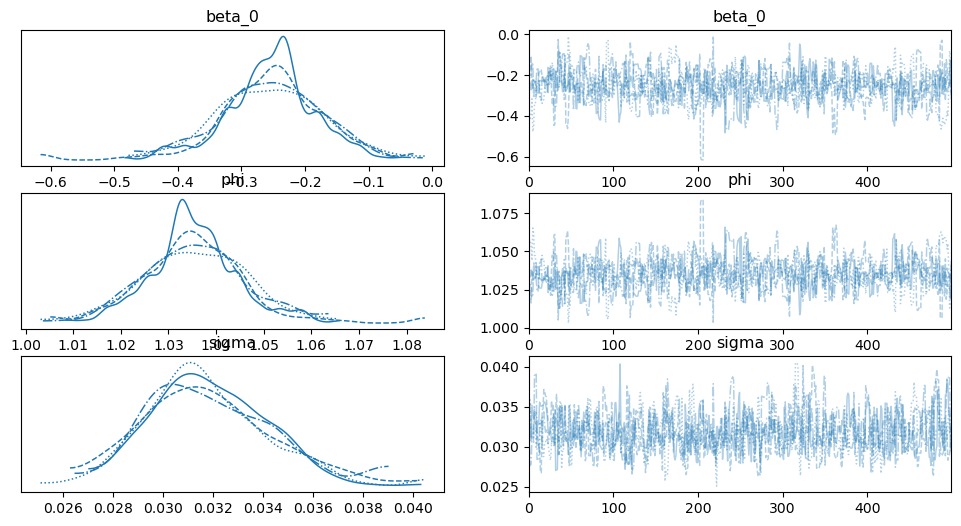

In [42]:
az.summary(trace)
az.plot_trace(trace)

In [44]:
n_forecast = 12

# Extract posterior samples
beta_0_samples = trace.posterior["beta_0"].values.flatten()
phi_samples = trace.posterior["phi"].values.flatten()
sigma_samples = trace.posterior["sigma"].values.flatten()

n_samples = len(beta_0_samples)

# Start from last observed value
last_y = y[-1]

# Store forecasts
forecast_log = np.zeros((n_forecast, n_samples))

for s in range(n_samples):
    y_prev = last_y
    
    for t in range(n_forecast):
        mu_t = beta_0_samples[s] + phi_samples[s] * y_prev
        
        # simulate next step
        y_next = np.random.normal(mu_t, sigma_samples[s])
        
        forecast_log[t, s] = y_next
        y_prev = y_next  # recursive!

# Convert back to price
forecast_price = np.exp(forecast_log)

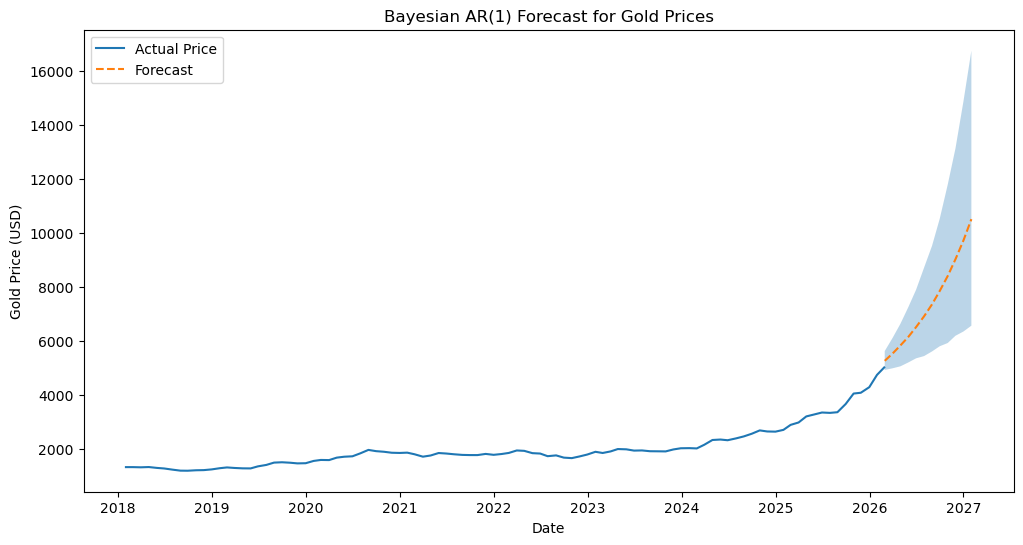

In [46]:
mean_preds = forecast_price.mean(axis=1)
lower = np.percentile(forecast_price, 2.5, axis=1)
upper = np.percentile(forecast_price, 97.5, axis=1)

# create future dates for future dataframe
future_dates = pd.date_range(
    start=gold_data_clean['Date'].iloc[-1] + pd.offsets.MonthBegin(1),
    periods=n_forecast,
    freq='MS'
)

plt.figure(figsize=(12,6))

# Historical data
plt.plot(gold_data_clean['Date'], gold_data_clean['USD'], label='Actual Price')

# Forecast
plt.plot(future_dates, mean_preds, linestyle='--', label='Forecast')

# Uncertainty
plt.fill_between(future_dates, lower, upper, alpha=0.3)

plt.xlabel("Date")
plt.ylabel("Gold Price (USD)")
plt.title("Bayesian AR(1) Forecast for Gold Prices")
plt.legend()
plt.show()


In [51]:
# Export for visualization page
np.savetxt('gold_preds.csv', mean_preds, delimiter=',')